# SEIRS-SEI Malaria Model — Weighted Human Transmission Parameter Calibration

Calibrating **tau_H**, **gamma**, and **omega** (human transmission parameters) with **time-weighted optimization**.

## Problem Statement

The human transmission parameters control the intrinsic incubation period, recovery rate, and loss of immunity. Weighted optimization gives more importance to early time periods to better capture initial dynamics.

**Parameters being calibrated:**
- **tau_H** (days): intrinsic incubation period — time from exposure to infectiousness
- **gamma** (1/day): recovery rate — inverse of infectious period
- **omega** (1/day): loss of immunity rate — inverse of immunity duration

**Weight Decay Methods:**
- **Exponential**: `weight = W0 * exp(-rate * days)` - Smooth, continuous decay
- **Step**: Higher weight for first year, then lower weight
- **Inverse**: `weight = W0 * (1 / (1 + days/365))` - Year-based decay

**Default values**: tau_H=10, gamma=1/120, omega=1/270

---
**Resumable execution**: Results are saved to `calibration_results_human.json` after each section.
If the notebook is interrupted, re-run from the top — completed sections will be loaded from file and skipped.

In [2]:
from weighted_optimization_shared import *
%matplotlib inline
import warnings, json, os
warnings.filterwarnings("ignore")
from scipy.optimize import minimize
import itertools

Climate data 2012-2023: 4383 days
Warm-up (2012-2016): 1827 days
Main period (2017-2023): 2556 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25
Loaded fitted humidity params from exponential: H0=44.9999, k=0.600000, phi=0.100001

Initial human compartments in 2012: N=8914, S_H=5365, E_H=446, I_H=1766, R_H=1337
Initial mosquito compartments in 2012: M=89140, S_M=85576, E_M=2673, I_M=891


In [3]:
RESULTS_FILE = os.path.join(os.getcwd(), 'calibration_results_human.json')

tau_H_candidates = [7, 10, 12, 14, 18, 21]
gamma_candidates = [1/7, 1/15, 1/30, 1/60, 1/120, 1/180]
omega_candidates = [1/180, 1/270, 1/365, 1/730]
bounds = [(1, 60), (1e-4, 1.0), (1e-5, 0.1)]
decay_rate = 0.005
initial_weight = 5.0
step_initial_weight = 5.0
step_later_weight = 1.0
inverse_scale = 365

saved = {}
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, 'r') as f:
        saved = json.load(f)
    print(f"Loaded saved results from {RESULTS_FILE}")
    for method, params in saved.items():
        print(f"  {method}: tau_H={params['tau_H']:.4f}, gamma={params['gamma']:.6f}, omega={params['omega']:.6f}")
else:
    print("No saved results found — will run all grid searches.")

if 'exponential' in saved:
    tau_H_optimal_exp = saved['exponential']['tau_H']
    gamma_optimal_exp = saved['exponential']['gamma']
    omega_optimal_exp = saved['exponential']['omega']
if 'step' in saved:
    tau_H_optimal_step = saved['step']['tau_H']
    gamma_optimal_step = saved['step']['gamma']
    omega_optimal_step = saved['step']['omega']
if 'inverse' in saved:
    tau_H_optimal_inv = saved['inverse']['tau_H']
    gamma_optimal_inv = saved['inverse']['gamma']
    omega_optimal_inv = saved['inverse']['omega']

No saved results found — will run all grid searches.


In [4]:
def save_result(method_name, tau_H, gamma, omega):
    data = json.load(open(RESULTS_FILE, 'r')) if os.path.exists(RESULTS_FILE) else {}
    data[method_name] = {'tau_H': float(tau_H), 'gamma': float(gamma), 'omega': float(omega)}
    with open(RESULTS_FILE, 'w') as f:
        json.dump(data, f, indent=2)
    print(f"  Saved {method_name} results to {RESULTS_FILE}")

---
## Section 1: Understanding the Weighting Approach

Before calibrating, let's understand how different weight functions affect the optimization.

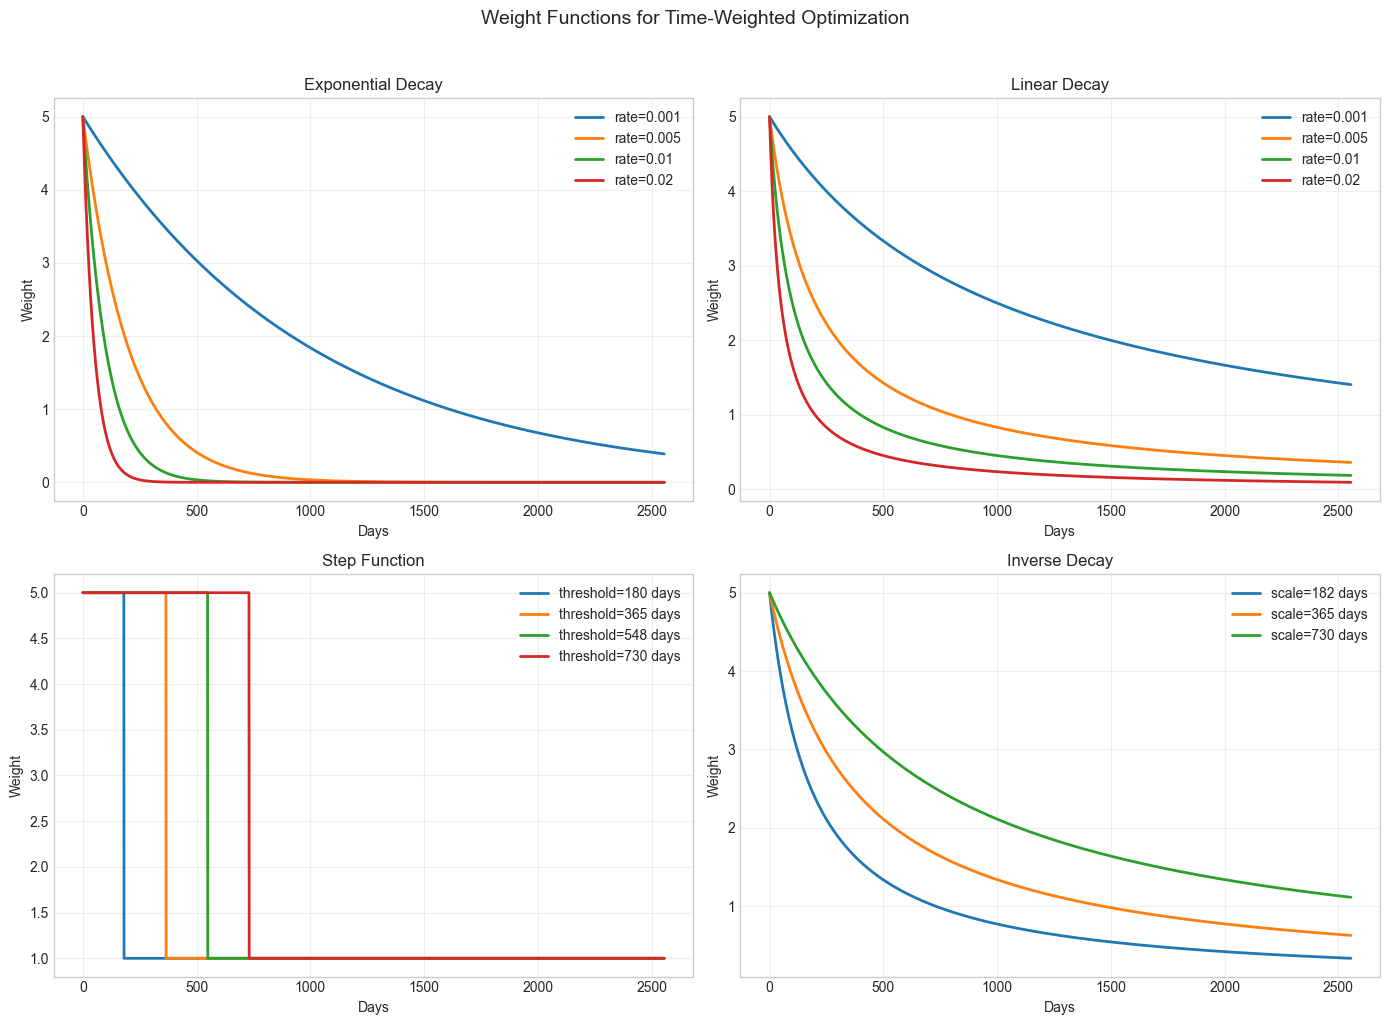

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
days = np.arange(0, 2556, 1)

ax1 = axes[0, 0]
for rate in [0.001, 0.005, 0.01, 0.02]:
    ax1.plot(days, 5.0 * np.exp(-rate * days), linewidth=2, label=f'rate={rate}')
ax1.set_title('Exponential Decay'); ax1.set_xlabel('Days'); ax1.set_ylabel('Weight'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
for rate in [0.001, 0.005, 0.01, 0.02]:
    ax2.plot(days, 5.0 / (1 + rate * days), linewidth=2, label=f'rate={rate}')
ax2.set_title('Linear Decay'); ax2.set_xlabel('Days'); ax2.set_ylabel('Weight'); ax2.legend(); ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
for thresh in [180, 365, 548, 730]:
    w = np.where(days <= thresh, 5.0, 1.0)
    ax3.plot(days, w, linewidth=2, label=f'threshold={thresh} days')
ax3.set_title('Step Function'); ax3.set_xlabel('Days'); ax3.set_ylabel('Weight'); ax3.legend(); ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
for scale in [182, 365, 730]:
    ax4.plot(days, 5.0 * (1.0 / (1.0 + days / scale)), linewidth=2, label=f'scale={scale} days')
ax4.set_title('Inverse Decay'); ax4.set_xlabel('Days'); ax4.set_ylabel('Weight'); ax4.legend(); ax4.grid(True, alpha=0.3)

plt.suptitle('Weight Functions for Time-Weighted Optimization', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 2: Grid Search with Exponential Weighting

In [8]:
if 'exponential' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Exponential Weighting")
    print("=" * 70)
    grid_size = len(tau_H_candidates) * len(gamma_candidates) * len(omega_candidates)
    print(f"Grid size: {len(tau_H_candidates)} x {len(gamma_candidates)} x {len(omega_candidates)} = {grid_size}")
    print(f"Weight: exponential decay, rate={decay_rate}, initial_weight={initial_weight}")
    print()

    best_params_exp = None
    best_mse_exp = 1e15

    for tau, gam, ome in itertools.product(tau_H_candidates, gamma_candidates, omega_candidates):
        mse = objective_function_weighted_human([tau, gam, ome],
                                         weight_decay='exponential',
                                         decay_rate=decay_rate,
                                         initial_weight=initial_weight)
        if mse < best_mse_exp:
            best_mse_exp = mse
            best_params_exp = (tau, gam, ome)
        print(f"  tau_H={tau:2d}, gamma={gam:.6f}, omega={ome:.6f} -> Weighted MSE={mse:>12,.2f}")

    print(f"\nBest from grid (Exponential): tau_H={best_params_exp[0]:.1f}, gamma={best_params_exp[1]:.6f}, omega={best_params_exp[2]:.6f}")
    print(f"  Weighted MSE = {best_mse_exp:,.2f}")
else:
    print("Exponential results already loaded — skipping grid search.")
    best_params_exp = (tau_H_optimal_exp, gamma_optimal_exp, omega_optimal_exp)

GRID SEARCH: Exponential Weighting
Grid size: 6 x 6 x 4 = 144
Weight: exponential decay, rate=0.005, initial_weight=5.0

  tau_H= 7, gamma=0.142857, omega=0.005556 -> Weighted MSE=1,468,819.15
  tau_H= 7, gamma=0.142857, omega=0.003704 -> Weighted MSE=1,468,819.15
  tau_H= 7, gamma=0.142857, omega=0.002740 -> Weighted MSE=1,468,819.15
  tau_H= 7, gamma=0.142857, omega=0.001370 -> Weighted MSE=1,468,819.15
  tau_H= 7, gamma=0.066667, omega=0.005556 -> Weighted MSE=1,468,819.15
  tau_H= 7, gamma=0.066667, omega=0.003704 -> Weighted MSE=1,468,819.15
  tau_H= 7, gamma=0.066667, omega=0.002740 -> Weighted MSE=1,468,819.15
  tau_H= 7, gamma=0.066667, omega=0.001370 -> Weighted MSE=1,468,819.15
  tau_H= 7, gamma=0.033333, omega=0.005556 -> Weighted MSE=1,468,819.15
  tau_H= 7, gamma=0.033333, omega=0.003704 -> Weighted MSE=1,468,819.15
  tau_H= 7, gamma=0.033333, omega=0.002740 -> Weighted MSE=1,468,819.15
  tau_H= 7, gamma=0.033333, omega=0.001370 -> Weighted MSE=1,468,819.15
  tau_H= 7, gam

In [9]:
if 'exponential' not in saved:
    print("Fine optimization with L-BFGS-B (Exponential)...")
    result_exp = minimize(
        lambda p: objective_function_weighted_human(p, weight_decay='exponential',
                                             decay_rate=decay_rate, initial_weight=initial_weight),
        list(best_params_exp), method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-8}
    )
    tau_H_optimal_exp, gamma_optimal_exp, omega_optimal_exp = result_exp.x
    print(f"  tau_H={tau_H_optimal_exp:.4f}, gamma={gamma_optimal_exp:.6f}, omega={omega_optimal_exp:.6f}")
    print(f"  Weighted MSE = {result_exp.fun:,.2f}")
    save_result('exponential', tau_H_optimal_exp, gamma_optimal_exp, omega_optimal_exp)
else:
    print(f"Exponential: tau_H={tau_H_optimal_exp:.4f}, gamma={gamma_optimal_exp:.6f}, omega={omega_optimal_exp:.6f}")

Fine optimization with L-BFGS-B (Exponential)...
  tau_H=21.0000, gamma=0.008333, omega=0.005556
  Weighted MSE = 169,279.98
  Saved exponential results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\weighted_optimization\calibration_results_human.json


---
## Section 3: Grid Search with Step Function Weighting

In [11]:
if 'step' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Step Function Weighting")
    print("=" * 70)
    grid_size = len(tau_H_candidates) * len(gamma_candidates) * len(omega_candidates)
    print(f"Grid size: {len(tau_H_candidates)} x {len(gamma_candidates)} x {len(omega_candidates)} = {grid_size}")
    print(f"Weight: step (first year: {step_initial_weight}x, after: {step_later_weight}x)")
    print()

    best_params_step = None
    best_mse_step = 1e15

    for tau, gam, ome in itertools.product(tau_H_candidates, gamma_candidates, omega_candidates):
        mse = objective_function_weighted_human([tau, gam, ome],
                                         weight_decay='step',
                                         initial_weight=step_initial_weight,
                                         step_later_weight=step_later_weight)
        if mse < best_mse_step:
            best_mse_step = mse
            best_params_step = (tau, gam, ome)
        print(f"  tau_H={tau:2d}, gamma={gam:.6f}, omega={ome:.6f} -> Weighted MSE={mse:>12,.2f}")

    print(f"\nBest from grid (Step): tau_H={best_params_step[0]:.1f}, gamma={best_params_step[1]:.6f}, omega={best_params_step[2]:.6f}")
    print(f"  Weighted MSE = {best_mse_step:,.2f}")
else:
    print("Step results already loaded — skipping grid search.")
    best_params_step = (tau_H_optimal_step, gamma_optimal_step, omega_optimal_step)

GRID SEARCH: Step Function Weighting
Grid size: 6 x 6 x 4 = 144
Weight: step (first year: 5.0x, after: 1.0x)

  tau_H= 7, gamma=0.142857, omega=0.005556 -> Weighted MSE=  902,736.25
  tau_H= 7, gamma=0.142857, omega=0.003704 -> Weighted MSE=  902,736.25
  tau_H= 7, gamma=0.142857, omega=0.002740 -> Weighted MSE=  902,736.25
  tau_H= 7, gamma=0.142857, omega=0.001370 -> Weighted MSE=  902,736.25
  tau_H= 7, gamma=0.066667, omega=0.005556 -> Weighted MSE=  902,736.25
  tau_H= 7, gamma=0.066667, omega=0.003704 -> Weighted MSE=  902,736.25
  tau_H= 7, gamma=0.066667, omega=0.002740 -> Weighted MSE=  902,736.25
  tau_H= 7, gamma=0.066667, omega=0.001370 -> Weighted MSE=  902,736.25
  tau_H= 7, gamma=0.033333, omega=0.005556 -> Weighted MSE=  902,736.25
  tau_H= 7, gamma=0.033333, omega=0.003704 -> Weighted MSE=  902,736.25
  tau_H= 7, gamma=0.033333, omega=0.002740 -> Weighted MSE=  902,736.25
  tau_H= 7, gamma=0.033333, omega=0.001370 -> Weighted MSE=  902,736.25
  tau_H= 7, gamma=0.016667

In [12]:
if 'step' not in saved:
    print("Fine optimization with L-BFGS-B (Step)...")
    result_step = minimize(
        lambda p: objective_function_weighted_human(p, weight_decay='step',
                                             initial_weight=step_initial_weight,
                                             step_later_weight=step_later_weight),
        list(best_params_step), method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-8}
    )
    tau_H_optimal_step, gamma_optimal_step, omega_optimal_step = result_step.x
    print(f"  tau_H={tau_H_optimal_step:.4f}, gamma={gamma_optimal_step:.6f}, omega={omega_optimal_step:.6f}")
    print(f"  Weighted MSE = {result_step.fun:,.2f}")
    save_result('step', tau_H_optimal_step, gamma_optimal_step, omega_optimal_step)
else:
    print(f"Step: tau_H={tau_H_optimal_step:.4f}, gamma={gamma_optimal_step:.6f}, omega={omega_optimal_step:.6f}")

Fine optimization with L-BFGS-B (Step)...
  tau_H=21.0000, gamma=0.005556, omega=0.001370
  Weighted MSE = 316,793.66
  Saved step results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\weighted_optimization\calibration_results_human.json


---
## Section 4: Grid Search with Inverse Decay Weighting

In [14]:
if 'inverse' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Inverse Decay Weighting")
    print("=" * 70)
    grid_size = len(tau_H_candidates) * len(gamma_candidates) * len(omega_candidates)
    print(f"Grid size: {len(tau_H_candidates)} x {len(gamma_candidates)} x {len(omega_candidates)} = {grid_size}")
    print(f"Weight: inverse decay, scale={inverse_scale} days")
    print()

    best_params_inv = None
    best_mse_inv = 1e15

    for tau, gam, ome in itertools.product(tau_H_candidates, gamma_candidates, omega_candidates):
        mse = objective_function_weighted_human([tau, gam, ome],
                                         weight_decay='inverse',
                                         initial_weight=initial_weight,
                                         inverse_scale=inverse_scale)
        if mse < best_mse_inv:
            best_mse_inv = mse
            best_params_inv = (tau, gam, ome)
        print(f"  tau_H={tau:2d}, gamma={gam:.6f}, omega={ome:.6f} -> Weighted MSE={mse:>12,.2f}")

    print(f"\nBest from grid (Inverse): tau_H={best_params_inv[0]:.1f}, gamma={best_params_inv[1]:.6f}, omega={best_params_inv[2]:.6f}")
    print(f"  Weighted MSE = {best_mse_inv:,.2f}")
else:
    print("Inverse results already loaded — skipping grid search.")
    best_params_inv = (tau_H_optimal_inv, gamma_optimal_inv, omega_optimal_inv)

GRID SEARCH: Inverse Decay Weighting
Grid size: 6 x 6 x 4 = 144
Weight: inverse decay, scale=365 days

  tau_H= 7, gamma=0.142857, omega=0.005556 -> Weighted MSE=1,039,566.62
  tau_H= 7, gamma=0.142857, omega=0.003704 -> Weighted MSE=1,039,566.62
  tau_H= 7, gamma=0.142857, omega=0.002740 -> Weighted MSE=1,039,566.62
  tau_H= 7, gamma=0.142857, omega=0.001370 -> Weighted MSE=1,039,566.62
  tau_H= 7, gamma=0.066667, omega=0.005556 -> Weighted MSE=1,039,566.62
  tau_H= 7, gamma=0.066667, omega=0.003704 -> Weighted MSE=1,039,566.62
  tau_H= 7, gamma=0.066667, omega=0.002740 -> Weighted MSE=1,039,566.62
  tau_H= 7, gamma=0.066667, omega=0.001370 -> Weighted MSE=1,039,566.62
  tau_H= 7, gamma=0.033333, omega=0.005556 -> Weighted MSE=1,039,566.62
  tau_H= 7, gamma=0.033333, omega=0.003704 -> Weighted MSE=1,039,566.62
  tau_H= 7, gamma=0.033333, omega=0.002740 -> Weighted MSE=1,039,566.62
  tau_H= 7, gamma=0.033333, omega=0.001370 -> Weighted MSE=1,039,566.62
  tau_H= 7, gamma=0.016667, omega

In [15]:
if 'inverse' not in saved:
    print("Fine optimization with L-BFGS-B (Inverse)...")
    result_inv = minimize(
        lambda p: objective_function_weighted_human(p, weight_decay='inverse',
                                             initial_weight=initial_weight,
                                             inverse_scale=inverse_scale),
        list(best_params_inv), method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-8}
    )
    tau_H_optimal_inv, gamma_optimal_inv, omega_optimal_inv = result_inv.x
    print(f"  tau_H={tau_H_optimal_inv:.4f}, gamma={gamma_optimal_inv:.6f}, omega={omega_optimal_inv:.6f}")
    print(f"  Weighted MSE = {result_inv.fun:,.2f}")
    save_result('inverse', tau_H_optimal_inv, gamma_optimal_inv, omega_optimal_inv)
else:
    print(f"Inverse: tau_H={tau_H_optimal_inv:.4f}, gamma={gamma_optimal_inv:.6f}, omega={omega_optimal_inv:.6f}")

Fine optimization with L-BFGS-B (Inverse)...
  tau_H=21.0000, gamma=0.005556, omega=0.001370
  Weighted MSE = 317,479.24
  Saved inverse results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\weighted_optimization\calibration_results_human.json


---
## Section 5: Comparison of All Weighting Methods

Compare the results from exponential, step, and inverse decay weighting, as well as unweighted optimization.

In [17]:
print("Running simulations for comparison...")

dates_default, IH_default = run_with_human_params(10, 1/120, 1/270)
print(f"Default: tau_H=10, gamma={1/120:.6f}, omega={1/270:.6f}")

print("\nRunning unweighted optimization...")
result_unweighted = minimize(
    objective_function_unweighted_human, [10, 1/120, 1/270],
    method='L-BFGS-B', bounds=bounds, options={'maxiter': 100, 'ftol': 1e-8}
)
tau_H_opt_unw, gamma_opt_unw, omega_opt_unw = result_unweighted.x
dates_unw, IH_unw = run_with_human_params(tau_H_opt_unw, gamma_opt_unw, omega_opt_unw)
print(f"Unweighted: tau_H={tau_H_opt_unw:.2f}, gamma={gamma_opt_unw:.6f}, omega={omega_opt_unw:.6f}")

print("\nRunning exponential weighting...")
dates_exp, IH_exp = run_with_human_params(tau_H_optimal_exp, gamma_optimal_exp, omega_optimal_exp)
print(f"Exponential: tau_H={tau_H_optimal_exp:.2f}, gamma={gamma_optimal_exp:.6f}, omega={omega_optimal_exp:.6f}")

print("\nRunning step function weighting...")
dates_step, IH_step = run_with_human_params(tau_H_optimal_step, gamma_optimal_step, omega_optimal_step)
print(f"Step: tau_H={tau_H_optimal_step:.2f}, gamma={gamma_optimal_step:.6f}, omega={omega_optimal_step:.6f}")

print("\nRunning inverse decay weighting...")
dates_inv, IH_inv = run_with_human_params(tau_H_optimal_inv, gamma_optimal_inv, omega_optimal_inv)
print(f"Inverse: tau_H={tau_H_optimal_inv:.2f}, gamma={gamma_optimal_inv:.6f}, omega={omega_optimal_inv:.6f}")

print("\nAll simulations completed!")

Running simulations for comparison...
Default: tau_H=10, gamma=0.008333, omega=0.003704

Running unweighted optimization...
Unweighted: tau_H=10.00, gamma=0.008333, omega=0.003704

Running exponential weighting...
Exponential: tau_H=21.00, gamma=0.008333, omega=0.005556

Running step function weighting...
Step: tau_H=21.00, gamma=0.005556, omega=0.001370

Running inverse decay weighting...
Inverse: tau_H=21.00, gamma=0.005556, omega=0.001370

All simulations completed!


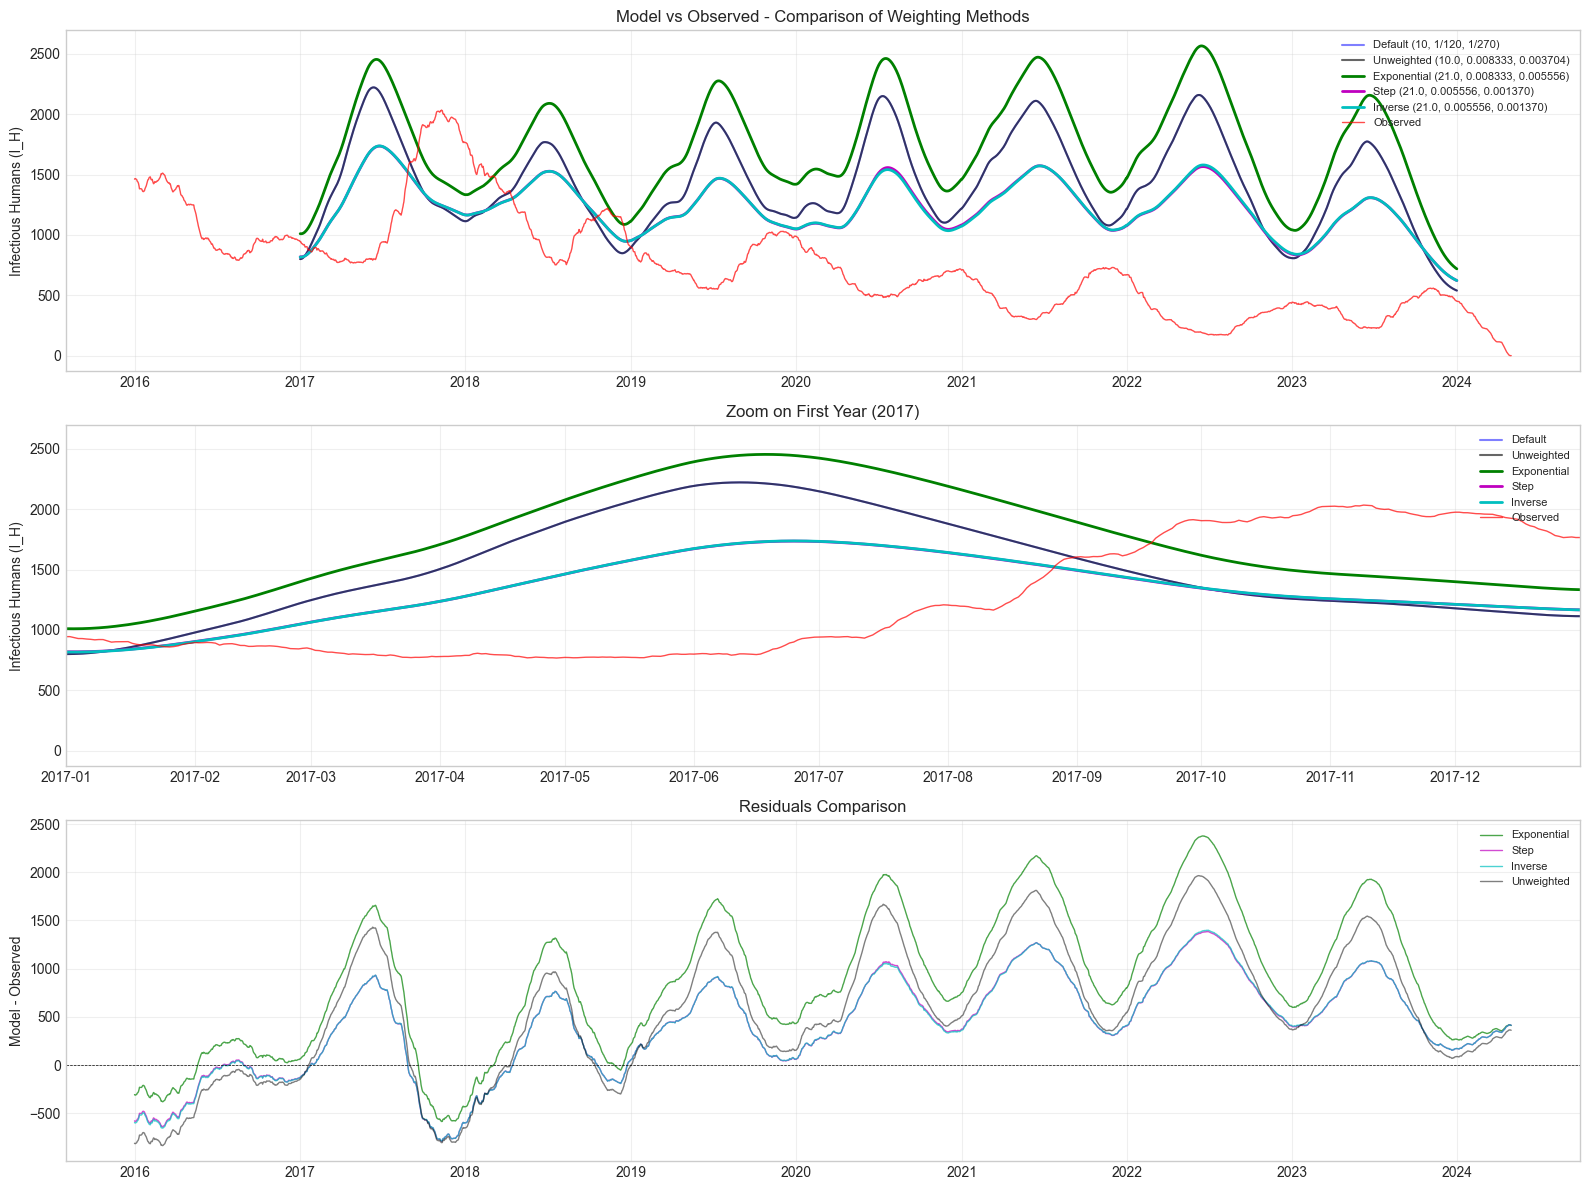

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

ax1 = axes[0]
ax1.plot(pd.to_datetime(dates_default), IH_default, 'b-', linewidth=1.5, alpha=0.5, label='Default (10, 1/120, 1/270)')
ax1.plot(pd.to_datetime(dates_unw), IH_unw, 'k-', linewidth=1.5, alpha=0.6, label=f'Unweighted ({tau_H_opt_unw:.1f}, {gamma_opt_unw:.6f}, {omega_opt_unw:.6f})')
ax1.plot(pd.to_datetime(dates_exp), IH_exp, 'g-', linewidth=2, label=f'Exponential ({tau_H_optimal_exp:.1f}, {gamma_optimal_exp:.6f}, {omega_optimal_exp:.6f})')
ax1.plot(pd.to_datetime(dates_step), IH_step, 'm-', linewidth=2, label=f'Step ({tau_H_optimal_step:.1f}, {gamma_optimal_step:.6f}, {omega_optimal_step:.6f})')
ax1.plot(pd.to_datetime(dates_inv), IH_inv, 'c-', linewidth=2, label=f'Inverse ({tau_H_optimal_inv:.1f}, {gamma_optimal_inv:.6f}, {omega_optimal_inv:.6f})')
ax1.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax1.set_ylabel('Infectious Humans (I_H)'); ax1.set_title('Model vs Observed - Comparison of Weighting Methods')
ax1.legend(loc='upper right', fontsize=8); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
first_year_end = pd.to_datetime('2017-12-31')
ax2.plot(pd.to_datetime(dates_default), IH_default, 'b-', linewidth=1.5, alpha=0.5, label='Default')
ax2.plot(pd.to_datetime(dates_unw), IH_unw, 'k-', linewidth=1.5, alpha=0.6, label='Unweighted')
ax2.plot(pd.to_datetime(dates_exp), IH_exp, 'g-', linewidth=2, label='Exponential')
ax2.plot(pd.to_datetime(dates_step), IH_step, 'm-', linewidth=2, label='Step')
ax2.plot(pd.to_datetime(dates_inv), IH_inv, 'c-', linewidth=2, label='Inverse')
ax2.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax2.set_xlim(pd.to_datetime('2017-01-01'), first_year_end)
ax2.set_ylabel('Infectious Humans (I_H)'); ax2.set_title('Zoom on First Year (2017)')
ax2.legend(loc='upper right', fontsize=8); ax2.grid(True, alpha=0.3)

ax3 = axes[2]
obs_dates_int = rural_cases_df['date'].astype(np.int64).values
for dates_arr, IH_arr, label, color, alpha in [
    (dates_exp, IH_exp, 'Exponential', 'g', 0.7),
    (dates_step, IH_step, 'Step', 'm', 0.7),
    (dates_inv, IH_inv, 'Inverse', 'c', 0.7),
    (dates_unw, IH_unw, 'Unweighted', 'k', 0.5),
]:
    mi = interp1d(pd.to_datetime(dates_arr).astype(np.int64), IH_arr, kind='linear', fill_value='extrapolate')
    ax3.plot(rural_cases_df['date'], mi(obs_dates_int) - rural_cases_df['active_total'].values,
             '-', color=color, linewidth=1.0, alpha=alpha, label=label)
ax3.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax3.set_ylabel('Model - Observed'); ax3.set_title('Residuals Comparison')
ax3.legend(loc='upper right', fontsize=8); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 6: Quantitative Comparison

In [20]:
def compute_mse(dates, IH):
    mi = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    return np.mean((mi(rural_cases_df['date'].astype(np.int64).values) - rural_cases_df['active_total'].values) ** 2)

def compute_first_year_mse(dates, IH):
    mi = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    mask = rural_cases_df['date'] <= pd.to_datetime('2017-12-31')
    return np.mean((mi(rural_cases_df.loc[mask, 'date'].astype(np.int64).values) - rural_cases_df.loc[mask, 'active_total'].values) ** 2)

method_results = {
    'Default':     {'dates': dates_default, 'IH': IH_default, 'tau_H': 10, 'gamma': 1/120, 'omega': 1/270},
    'Unweighted':  {'dates': dates_unw,     'IH': IH_unw,     'tau_H': tau_H_opt_unw, 'gamma': gamma_opt_unw, 'omega': omega_opt_unw},
    'Exponential': {'dates': dates_exp,     'IH': IH_exp,     'tau_H': tau_H_optimal_exp, 'gamma': gamma_optimal_exp, 'omega': omega_optimal_exp},
    'Step':        {'dates': dates_step,    'IH': IH_step,    'tau_H': tau_H_optimal_step, 'gamma': gamma_optimal_step, 'omega': omega_optimal_step},
    'Inverse':     {'dates': dates_inv,     'IH': IH_inv,     'tau_H': tau_H_optimal_inv, 'gamma': gamma_optimal_inv, 'omega': omega_optimal_inv},
}

print("=" * 80)
print("QUANTITATIVE COMPARISON")
print("=" * 80)
print(f"{'Method':<15} {'Overall MSE':>15} {'First Year MSE':>15} {'tau_H':>8} {'gamma':>12} {'omega':>12}")
print("-" * 80)

for name, data in method_results.items():
    overall = compute_mse(data['dates'], data['IH'])
    first_yr = compute_first_year_mse(data['dates'], data['IH'])
    print(f"{name:<15} {overall:>15,.2f} {first_yr:>15,.2f} {data['tau_H']:>8.2f} {data['gamma']:>12.6f} {data['omega']:>12.6f}")

print("=" * 80)

QUANTITATIVE COMPARISON
Method              Overall MSE  First Year MSE    tau_H        gamma        omega
--------------------------------------------------------------------------------
Default              773,780.36      426,080.54    10.00     0.008333     0.003704
Unweighted           773,780.36      426,080.54    10.00     0.008333     0.003704
Exponential        1,235,716.64      430,396.82    21.00     0.008333     0.005556
Step                 416,594.53      222,198.29    21.00     0.005556     0.001370
Inverse              418,212.53      225,462.12    21.00     0.005556     0.001370


---
## Summary: Best Parameters

In [22]:
saved = json.load(open(RESULTS_FILE, 'r')) if os.path.exists(RESULTS_FILE) else {}

print("=" * 70)
print("BEST WEIGHTED PARAMETERS (Human Transmission)")
print("=" * 70)

for method in ['exponential', 'step', 'inverse']:
    params = saved.get(method, {})
    if params:
        tau = params['tau_H']
        gam = params['gamma']
        ome = params['omega']
        print(f"\n{method.upper()}:")
        print(f"  tau_H = {tau:.4f} days (incubation period)")
        print(f"  gamma = {gam:.6f} (infectious period = {1/gam:.1f} days)")
        print(f"  omega = {ome:.6f} (immunity duration = {1/ome:.1f} days)")

print("\n" + "=" * 70)

BEST WEIGHTED PARAMETERS (Human Transmission)

EXPONENTIAL:
  tau_H = 21.0000 days (incubation period)
  gamma = 0.008333 (infectious period = 120.0 days)
  omega = 0.005556 (immunity duration = 180.0 days)

STEP:
  tau_H = 21.0000 days (incubation period)
  gamma = 0.005556 (infectious period = 180.0 days)
  omega = 0.001370 (immunity duration = 730.0 days)

INVERSE:
  tau_H = 21.0000 days (incubation period)
  gamma = 0.005556 (infectious period = 180.0 days)
  omega = 0.001370 (immunity duration = 730.0 days)

